# Energy Consumption Analysis — ESP32 Strawberry Monitoring System

Analyses PPK2 (Power Profiler Kit 2) current and power data for every ESP32 node in the system.

| Node | CSV file location |
|------|-------------------|
| Master | `PPK2 Data/CSV/Master/Master_Energy_*.csv` |
| Node 1 | `PPK2 Data/CSV/Node1/Node1_energy.csv` |
| Node 2 | `PPK2 Data/CSV/Node2/Node2_energy.csv` |
| MQ3 *(pending)* | — add path when available — |

**PPK2 settings used:** 10 000 samples/second, 3.3 V supply, ~2-hour recording per node.  
**Analysis window:** middle hour (30 – 90 min) to exclude start-up transients.

## 1. Imports and Configuration

Update the paths and constants below if your data lives in a different location.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

# ── Shared constants ──────────────────────────────────────────────────────────
SUPPLY_VOLTAGE    = 3.3    # V  (ESP32 operating voltage)
DOWNSAMPLE_FACTOR = 100    # 10 000 Hz → 100 Hz  (Master / Node1 / Node2 files)
START_TIME_MS     = 30 * 60 * 1000   # 1 800 000 ms  (30 min)  — middle-hour window
END_TIME_MS       = 90 * 60 * 1000   # 5 400 000 ms  (90 min)

# ── File paths ────────────────────────────────────────────────────────────────
PPK2_MASTER_DIR  = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\Master"
PPK2_NODE1_PATH  = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\Node1\Node1_energy.csv"
PPK2_NODE2_PATH  = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\Node2\Node2_energy.csv"

# MQ3 — two 5-minute recordings at 100 Hz (already downsampled by PPK2 app)
PPK2_MQ3_FILE1   = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\MQ3\MQ3_1.csv"
PPK2_MQ3_FILE2   = r"c:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\MQ3\MQ3_2.csv"

# ── Master file selection ─────────────────────────────────────────────────────
SELECTED_MASTER_INDEX = 1   # 0-based index into sorted master_files list

master_files = sorted(glob.glob(f"{PPK2_MASTER_DIR}/*.csv"))
print("=" * 65)
print("DETECTED MASTER PPK2 FILES")
print("=" * 65)
for i, f in enumerate(master_files):
    mb = os.path.getsize(f) / 1024**2
    marker = " ◄ selected" if i == SELECTED_MASTER_INDEX else ""
    print(f"  [{i}] {os.path.basename(f)}  ({mb:.1f} MB){marker}")
print("=" * 65)
print(f"\nSupply voltage : {SUPPLY_VOLTAGE} V")
print(f"Master/Node window : {START_TIME_MS//60000}–{END_TIME_MS//60000} min (middle hour)")
print(f"Master/Node downsample : every {DOWNSAMPLE_FACTOR}th sample → 100 Hz")
print(f"\nMQ3 files  (5-min, already 100 Hz — loaded in full):")
for f in [PPK2_MQ3_FILE1, PPK2_MQ3_FILE2]:
    mb = os.path.getsize(f) / 1024**2 if os.path.exists(f) else 0
    print(f"  {os.path.basename(f)}  ({mb:.2f} MB)")

DETECTED MASTER PPK2 FILES
  [0] Master_Energy_1.csv  (1970.3 MB)
  [1] Master_Energy_2.csv  (1952.9 MB) ◄ selected
  [2] Master_Energy_3.csv  (1970.9 MB)

Supply voltage : 3.3 V
Master/Node window : 30–90 min (middle hour)
Master/Node downsample : every 100th sample → 100 Hz

MQ3 files  (5-min, already 100 Hz — loaded in full):
  MQ3_1.csv  (0.76 MB)
  MQ3_2.csv  (0.76 MB)


## 2. Load Master Node Energy Data (Middle Hour)

In [2]:
%%time
selected_master = master_files[SELECTED_MASTER_INDEX]
print(f"Loading  →  {os.path.basename(selected_master)}")
print(f"Filtering for {START_TIME_MS//60000}–{END_TIME_MS//60000} min window (reading in 1 M-row chunks)…\n")

chunks = []
for chunk in pd.read_csv(selected_master, chunksize=1_000_000):
    mask = (chunk['Timestamp(ms)'] >= START_TIME_MS) & (chunk['Timestamp(ms)'] <= END_TIME_MS)
    part = chunk[mask].copy()
    if len(part):
        chunks.append(part)
    if chunk['Timestamp(ms)'].min() > END_TIME_MS:
        break

master_raw = pd.concat(chunks, ignore_index=True)

print(f"✓ Loaded {len(master_raw):>12,} rows")
print(f"  Timestamp range : {master_raw['Timestamp(ms)'].min():,} – {master_raw['Timestamp(ms)'].max():,} ms")
print(f"  Duration        : {(master_raw['Timestamp(ms)'].max() - master_raw['Timestamp(ms)'].min()) / 1000:.1f} s")
master_raw.head(3)

Loading  →  Master_Energy_2.csv
Filtering for 30–90 min window (reading in 1 M-row chunks)…

✓ Loaded   36,000,001 rows
  Timestamp range : 1,800,000.0 – 5,400,000.0 ms
  Duration        : 3600.0 s
CPU times: total: 26 s
Wall time: 45.8 s


,Timestamp(ms),Current(uA),D0-D7
0,1800000.0,183381.656,0
1,1800000.1,183918.047,0
2,1800000.2,183791.047,0


## 3. Load Node 1 and Node 2 Energy Data

In [3]:
def load_middle_hour_ppk2(file_path, node_name):
    """Load the 30-90 minute window from a large PPK2 CSV via chunking."""
    print(f"\nLoading {node_name}  →  {os.path.basename(file_path)}")
    if not os.path.exists(file_path):
        print(f"  ⚠ File not found: {file_path}")
        return None
    chunks = []
    try:
        for chunk in pd.read_csv(file_path, chunksize=1_000_000):
            if 'Timestamp(ms)' not in chunk.columns or 'Current(uA)' not in chunk.columns:
                print(f"  ⚠ Unexpected columns: {list(chunk.columns)}")
                return None
            mask = (chunk['Timestamp(ms)'] >= START_TIME_MS) & (chunk['Timestamp(ms)'] <= END_TIME_MS)
            part = chunk[mask].copy()
            if len(part):
                chunks.append(part)
            if chunk['Timestamp(ms)'].max() > END_TIME_MS:
                break
    except Exception as exc:
        print(f"  ⚠ Error: {exc}")
        return None
    if not chunks:
        print(f"  ⚠ No data in {START_TIME_MS//60000}–{END_TIME_MS//60000} min window")
        return None
    raw = pd.concat(chunks, ignore_index=True)
    print(f"  ✓ {len(raw):,} rows  |  avg {raw['Current(uA)'].mean()/1000:.3f} mA")
    return raw


def load_full_ppk2(file_path, node_name):
    """Load a complete short PPK2 CSV (no time filtering — for 5-min MQ3 files)."""
    print(f"\nLoading {node_name}  →  {os.path.basename(file_path)}")
    if not os.path.exists(file_path):
        print(f"  ⚠ File not found: {file_path}")
        return None
    try:
        raw = pd.read_csv(file_path)
        if 'Timestamp(ms)' not in raw.columns or 'Current(uA)' not in raw.columns:
            print(f"  ⚠ Unexpected columns: {list(raw.columns)}")
            return None
        dur_s = (raw['Timestamp(ms)'].max() - raw['Timestamp(ms)'].min()) / 1000
        hz    = len(raw) / dur_s if dur_s > 0 else 0
        print(f"  ✓ {len(raw):,} rows  |  {dur_s:.0f} s  |  ~{hz:.0f} Hz  "
              f"|  avg {raw['Current(uA)'].mean()/1000:.3f} mA")
        return raw
    except Exception as exc:
        print(f"  ⚠ Error: {exc}")
        return None


# ── Load Node 1 & Node 2 ──────────────────────────────────────────────────────
print("=" * 65)
print("LOADING NODE PPK2 FILES  (middle-hour, chunked)")
print("=" * 65)
node1_raw = load_middle_hour_ppk2(PPK2_NODE1_PATH, "Node 1")
node2_raw = load_middle_hour_ppk2(PPK2_NODE2_PATH, "Node 2")

# ── Load MQ3 — both 5-minute recordings ──────────────────────────────────────
print("\n" + "=" * 65)
print("LOADING MQ3 PPK2 FILES  (full 5-min recordings, already 100 Hz)")
print("=" * 65)
mq3_raw1 = load_full_ppk2(PPK2_MQ3_FILE1, "MQ3 run 1")
mq3_raw2 = load_full_ppk2(PPK2_MQ3_FILE2, "MQ3 run 2")

# Average the two MQ3 runs to get a single representative trace
if mq3_raw1 is not None and mq3_raw2 is not None:
    # Both have the same number of rows and timestamps — average current directly
    mq3_raw = mq3_raw1.copy()
    mq3_raw['Current(uA)'] = (mq3_raw1['Current(uA)'].values +
                               mq3_raw2['Current(uA)'].values) / 2
    avg1 = mq3_raw1['Current(uA)'].mean() / 1000
    avg2 = mq3_raw2['Current(uA)'].mean() / 1000
    diff = abs(avg1 - avg2) / max(avg1, avg2) * 100
    flag = "✅" if diff < 10 else "⚠"
    print(f"\n  Run 1 avg : {avg1:.3f} mA")
    print(f"  Run 2 avg : {avg2:.3f} mA")
    print(f"  {flag} Difference : {diff:.1f}%  "
          f"({'consistent' if diff < 10 else 'larger than expected — check setup'})")
    print(f"  → Using averaged trace for analysis  "
          f"({mq3_raw['Current(uA)'].mean()/1000:.3f} mA avg)")
elif mq3_raw1 is not None:
    mq3_raw = mq3_raw1
    print("\n  ⚠ Only run 1 available — using single recording")
elif mq3_raw2 is not None:
    mq3_raw = mq3_raw2
    print("\n  ⚠ Only run 2 available — using single recording")
else:
    mq3_raw = None

# ── Loading summary ───────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("LOADING SUMMARY")
print("=" * 65)
for label, raw in [("Master", master_raw), ("Node 1", node1_raw),
                   ("Node 2", node2_raw),  ("MQ3",   mq3_raw)]:
    if raw is not None and len(raw) > 100:
        print(f"  ✅ {label:<8} {len(raw):>12,} rows")
    else:
        print(f"  ❌ {label:<8} FAILED / missing")
print("=" * 65)

LOADING NODE PPK2 FILES  (middle-hour, chunked)

Loading Node 1  →  Node1_energy.csv
  ✓ 36,000,001 rows  |  avg 64.752 mA

Loading Node 2  →  Node2_energy.csv
  ✓ 36,000,001 rows  |  avg 66.144 mA

LOADING MQ3 PPK2 FILES  (full 5-min recordings, already 100 Hz)

Loading MQ3 run 1  →  MQ3_1.csv
  ✓ 30,001 rows  |  300 s  |  ~100 Hz  |  avg 310.070 mA

Loading MQ3 run 2  →  MQ3_2.csv
  ✓ 30,001 rows  |  300 s  |  ~100 Hz  |  avg 315.660 mA

  Run 1 avg : 310.070 mA
  Run 2 avg : 315.660 mA
  ✅ Difference : 1.8%  (consistent)
  → Using averaged trace for analysis  (312.865 mA avg)

LOADING SUMMARY
  ✅ Master     36,000,001 rows
  ✅ Node 1     36,000,001 rows
  ✅ Node 2     36,000,001 rows
  ✅ MQ3            30,001 rows


## 4. Process and Downsample All Node Data

Convert µA → mA, calculate power in mW, and downsample to 100 Hz for efficient plotting.

In [4]:
def process_ppk2(raw_df, downsample=True):
    """
    Convert raw PPK2 DataFrame into analysis-ready form.

    Parameters
    ----------
    raw_df    : DataFrame returned by load_middle_hour_ppk2 / load_full_ppk2
    downsample: If True (default) decimate by DOWNSAMPLE_FACTOR, reducing
                10 000 Hz → 100 Hz.  Set to False for files already at 100 Hz
                (e.g. the 5-min MQ3 recordings exported at 100 Hz by PPK2 app).
    """
    if raw_df is None or len(raw_df) < 2:
        return None

    df = raw_df.iloc[::DOWNSAMPLE_FACTOR].copy() if downsample else raw_df.copy()
    df = df.reset_index(drop=True)
    df['time_sec']   = (df['Timestamp(ms)'] - df['Timestamp(ms)'].iloc[0]) / 1000
    df['current_ma'] = df['Current(uA)'] / 1000
    df['power_mw']   = df['current_ma'] * SUPPLY_VOLTAGE
    return df


# Process all nodes
master_df = process_ppk2(master_raw)                       # 10 000 Hz  → 100 Hz
node1_df  = process_ppk2(node1_raw)                        # 10 000 Hz  → 100 Hz
node2_df  = process_ppk2(node2_raw)                        # 10 000 Hz  → 100 Hz
mq3_df    = process_ppk2(mq3_raw, downsample=False)        # already 100 Hz

print("Processed data shapes:")
for label, df in [("Master", master_df), ("Node 1", node1_df),
                  ("Node 2", node2_df),  ("MQ3",   mq3_df)]:
    if df is not None:
        dur = df['time_sec'].max() - df['time_sec'].min()
        print(f"  {label:<8} {len(df):>10,} rows  |  "
              f"{dur/60:.1f} min  |  "
              f"avg {df['current_ma'].mean():.3f} mA  |  "
              f"avg {df['power_mw'].mean():.3f} mW")
    else:
        print(f"  {label:<8} ❌  not available")

Processed data shapes:
  Master      360,001 rows  |  60.0 min  |  avg 88.789 mA  |  avg 293.003 mW
  Node 1      360,001 rows  |  60.0 min  |  avg 64.751 mA  |  avg 213.677 mW
  Node 2      360,001 rows  |  60.0 min  |  avg 66.127 mA  |  avg 218.220 mW
  MQ3          30,001 rows  |  5.0 min  |  avg 312.865 mA  |  avg 1032.454 mW


## 5. Individual Node Power Profiles

One panel per available node. Green dotted lines mark the expected 15-minute data transmission cycles.

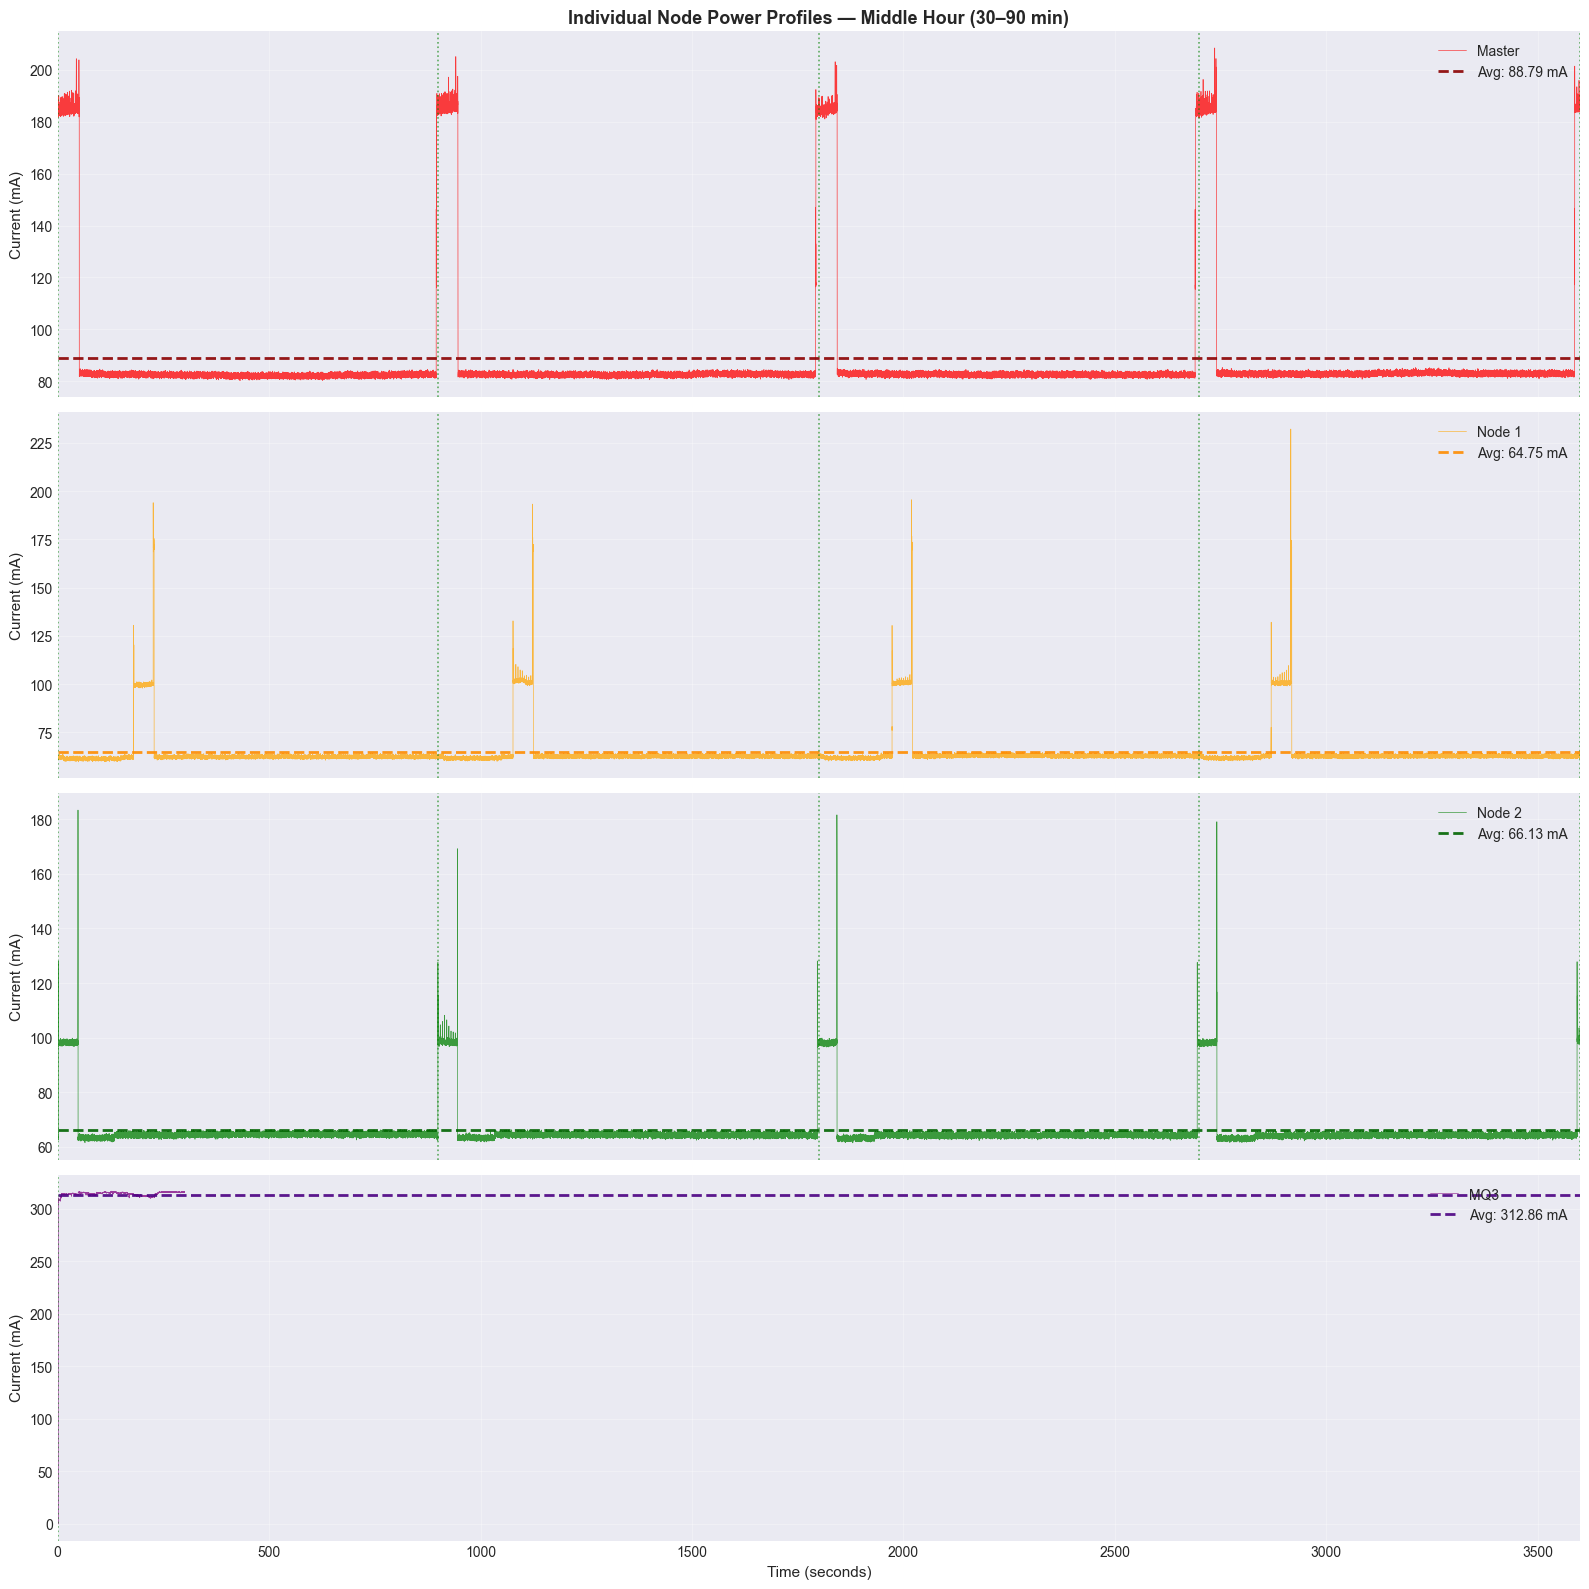

Green dotted lines = expected 15-min data transmission cycles


In [5]:
NODE_STYLES = {
    "Master": (master_df, "red",    "darkred"),
    "Node 1": (node1_df,  "orange", "darkorange"),
    "Node 2": (node2_df,  "green",  "darkgreen"),
    "MQ3":    (mq3_df,    "purple", "indigo"),
}

available = [(name, df, c, lc) for name, (df, c, lc) in NODE_STYLES.items() if df is not None]
n = len(available)

fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=True)
if n == 1:
    axes = [axes]

TX_TIMES = [t * 60 for t in [0, 15, 30, 45, 60]]   # transmission cycle markers (sec)

for ax, (name, df, color, lc) in zip(axes, available):
    ax.plot(df['time_sec'], df['current_ma'], linewidth=0.5, color=color, alpha=0.75, label=name)
    avg = df['current_ma'].mean()
    ax.axhline(avg, color=lc, linestyle='--', linewidth=2,
               label=f"Avg: {avg:.2f} mA", alpha=0.9)
    for t in TX_TIMES:
        if t <= df['time_sec'].max():
            ax.axvline(t, color='green', linestyle=':', linewidth=1.2, alpha=0.6)
    ax.set_ylabel('Current (mA)', fontsize=11)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 3600)

axes[0].set_title('Individual Node Power Profiles — Middle Hour (30–90 min)',
                  fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()
print("Green dotted lines = expected 15-min data transmission cycles")

## 6. Multi-Node Power Comparison

Overlay all nodes on one axes, then show a bar chart of average power with the total system line.

**Expected pattern:**
- **Master** draws significantly more current — it runs SGP40 TVOC/eCO2, DHT22, and MQ3 sensors **plus** handles UART aggregation, receiving data from all other nodes and forwarding it to the Raspberry Pi 5. The additional UART coordination workload is what drives its higher consumption compared to the plain sensor nodes.
- **Node 1 ≈ Node 2** — both are simple sensor nodes (DHT22 + SGP40 + MQ3) with identical firmware and hardware, so their average power should be very similar. Any large difference between the two would indicate a hardware or wiring issue.

> **Note:** The camera is controlled by the Raspberry Pi 5, not any ESP32 node — it does not appear in these energy measurements.

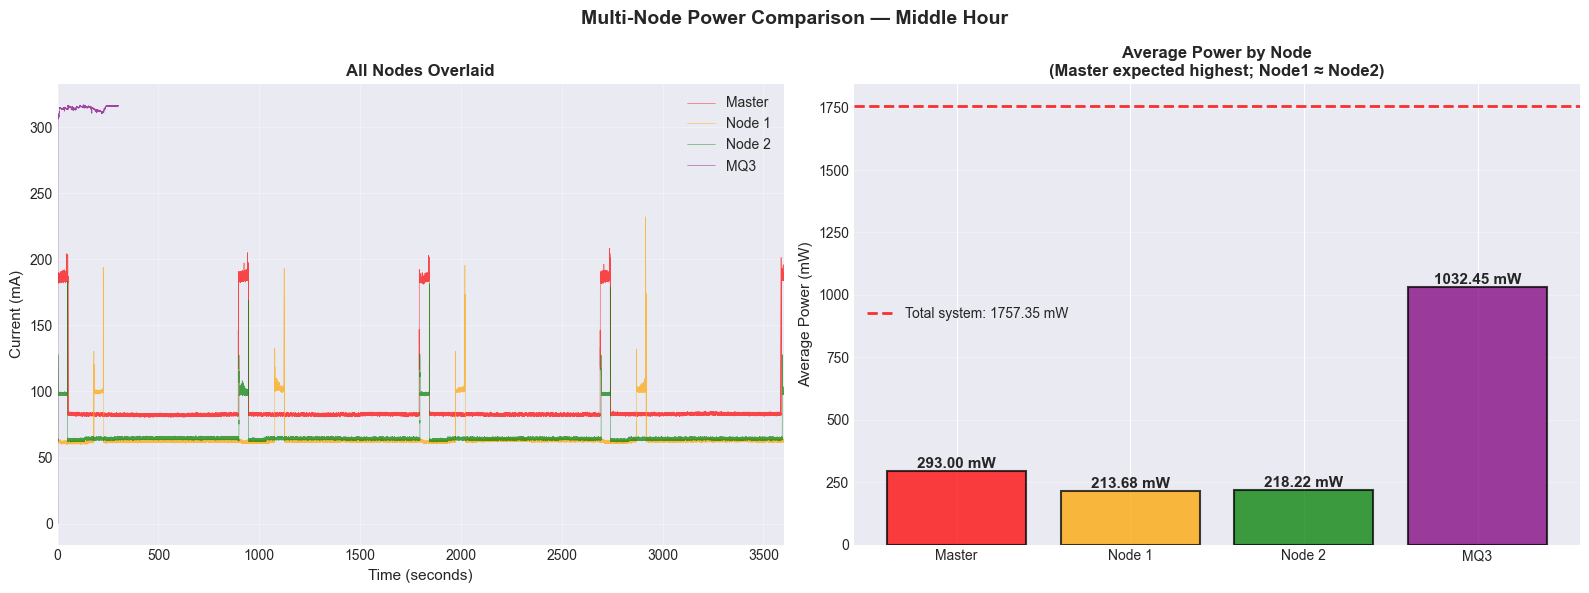


Node          Avg mA   Peak mA   Min mA    Avg mW   Idle %  Active %
---------------------------------------------------------------------------
Master        88.789   208.440   80.166   293.003    94.0%      6.0%
Node 1        64.751   232.132   59.804   213.677    94.6%      5.4%
Node 2        66.127   183.348   61.483   218.220    94.6%      5.4%
MQ3          312.865   316.846    0.002  1032.454   100.0%      0.0%
---------------------------------------------------------------------------
TOTAL                                    1757.355 mW  =  1.7574 W

SANITY CHECKS
-------------------------------------------------------
  ✅ Master vs Node 1 : 293.00 mW vs 213.68 mW  (Master is 1.4× higher)
  ✅ Master vs Node 2 : 293.00 mW vs 218.22 mW  (Master is 1.3× higher)
  ✅ Node 1 vs Node 2 : 213.68 mW vs 218.22 mW  (difference: 2.1%  — within tolerance)
-------------------------------------------------------


In [6]:
available = [(name, df, c, lc) for name, (df, c, lc) in NODE_STYLES.items() if df is not None]

fig, (ax_over, ax_bar) = plt.subplots(1, 2, figsize=(16, 6))

# ── Overlay plot ──────────────────────────────────────────────────────────────
for name, df, color, lc in available:
    ax_over.plot(df['time_sec'], df['current_ma'], linewidth=0.4, alpha=0.7, label=name, color=color)
ax_over.set_xlabel('Time (seconds)', fontsize=11)
ax_over.set_ylabel('Current (mA)', fontsize=11)
ax_over.set_title('All Nodes Overlaid', fontsize=12, fontweight='bold')
ax_over.legend(fontsize=10)
ax_over.grid(True, alpha=0.3)
ax_over.set_xlim(0, 3600)

# ── Bar chart ─────────────────────────────────────────────────────────────────
names   = [n     for n, df, c, lc in available]
colors  = [c     for n, df, c, lc in available]
powers  = [df['power_mw'].mean() for n, df, c, lc in available]
total   = sum(powers)

bars = ax_bar.bar(names, powers, color=colors, alpha=0.75, edgecolor='black', linewidth=1.5)
for bar, pw in zip(bars, powers):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{pw:.2f} mW', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax_bar.axhline(total, color='red', linestyle='--', linewidth=2,
               label=f'Total system: {total:.2f} mW', alpha=0.8)
ax_bar.set_ylabel('Average Power (mW)', fontsize=11)
ax_bar.set_title('Average Power by Node\n(Master expected highest; Node1 ≈ Node2)',
                 fontsize=12, fontweight='bold')
ax_bar.legend(fontsize=10)
ax_bar.grid(True, alpha=0.3, axis='y')

plt.suptitle('Multi-Node Power Comparison — Middle Hour', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Statistics table ──────────────────────────────────────────────────────────
threshold_global = {
    name: df['current_ma'].mean() + 1.5 * df['current_ma'].std()
    for name, df, c, lc in available
}

print("\n" + "=" * 75)
print(f"{'Node':<10} {'Avg mA':>9} {'Peak mA':>9} {'Min mA':>8} "
      f"{'Avg mW':>9} {'Idle %':>8} {'Active %':>9}")
print("-" * 75)

node_powers = {}
total_power = 0
for name, df, color, lc in available:
    thr      = threshold_global[name]
    idle_pct = (df['current_ma'] <= thr).mean() * 100
    act_pct  = 100 - idle_pct
    avg_mw   = df['power_mw'].mean()
    node_powers[name] = avg_mw
    total_power += avg_mw
    print(f"{name:<10} {df['current_ma'].mean():>9.3f} {df['current_ma'].max():>9.3f} "
          f"{df['current_ma'].min():>8.3f} {avg_mw:>9.3f} {idle_pct:>7.1f}% {act_pct:>8.1f}%")

print("-" * 75)
print(f"{'TOTAL':<10} {'':>9} {'':>9} {'':>8} {total_power:>9.3f} mW  =  {total_power/1000:.4f} W")
print("=" * 75)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print("\nSANITY CHECKS")
print("-" * 55)

master_pw = node_powers.get("Master")
node1_pw  = node_powers.get("Node 1")
node2_pw  = node_powers.get("Node 2")

if master_pw and node1_pw:
    ratio = master_pw / node1_pw
    flag  = "✅" if master_pw > node1_pw else "⚠"
    print(f"  {flag} Master vs Node 1 : {master_pw:.2f} mW vs {node1_pw:.2f} mW  "
          f"(Master is {ratio:.1f}× higher)")

if master_pw and node2_pw:
    ratio = master_pw / node2_pw
    flag  = "✅" if master_pw > node2_pw else "⚠"
    print(f"  {flag} Master vs Node 2 : {master_pw:.2f} mW vs {node2_pw:.2f} mW  "
          f"(Master is {ratio:.1f}× higher)")

if node1_pw and node2_pw:
    diff_pct = abs(node1_pw - node2_pw) / max(node1_pw, node2_pw) * 100
    flag     = "✅" if diff_pct < 15 else ("⚠" if diff_pct < 30 else "❌")
    print(f"  {flag} Node 1 vs Node 2 : {node1_pw:.2f} mW vs {node2_pw:.2f} mW  "
          f"(difference: {diff_pct:.1f}%  — {'within tolerance' if diff_pct < 15 else 'larger than expected — check wiring'})")

print("-" * 55)

## 7. Current Distribution Analysis

Histograms reveal bimodal distributions (idle + active peaks) and a pie chart shows each node's share of total system power.

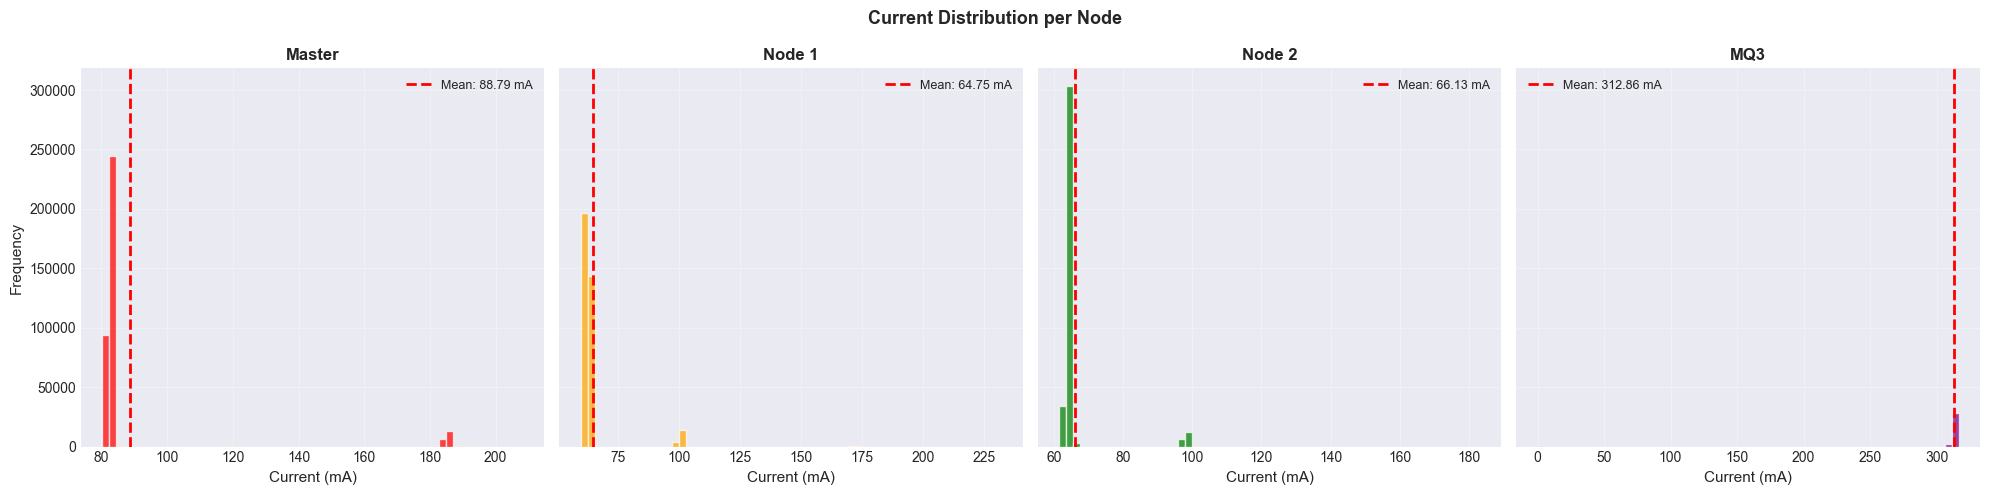

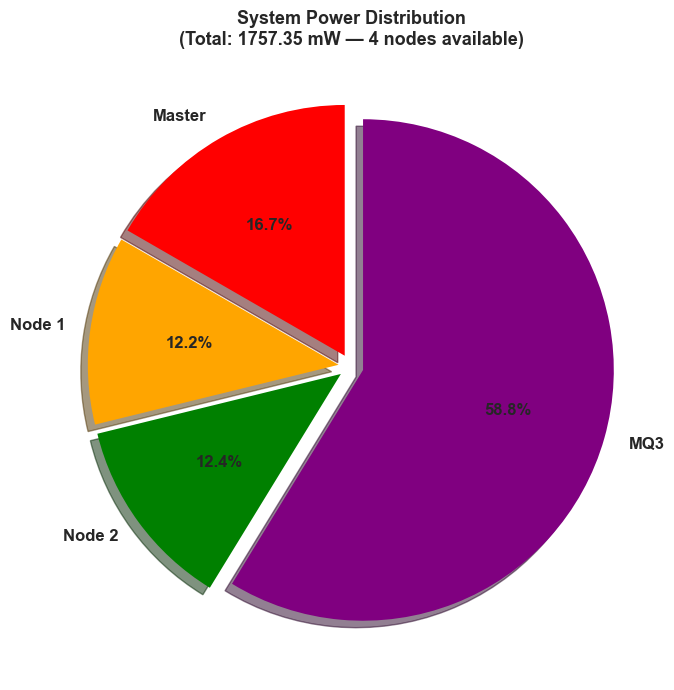

In [7]:
available = [(name, df, c, lc) for name, (df, c, lc) in NODE_STYLES.items() if df is not None]
n = len(available)

# ── Side-by-side histograms ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, (name, df, color, lc) in zip(axes, available):
    ax.hist(df['current_ma'], bins=60, color=color, alpha=0.72, edgecolor='white')
    mean_val = df['current_ma'].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_val:.2f} mA')
    ax.set_xlabel('Current (mA)', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Frequency', fontsize=11)
fig.suptitle('Current Distribution per Node', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Pie chart — power share ───────────────────────────────────────────────────
avg_powers = [df['power_mw'].mean() for _, df, _, _ in available]
names_list = [name                   for name, _, _, _ in available]
colors_list = [c                     for _, _, c, _ in available]
total       = sum(avg_powers)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    avg_powers, labels=names_list, colors=colors_list,
    autopct='%1.1f%%', startangle=90,
    explode=[0.05] * n, shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
ax.set_title(f'System Power Distribution\n(Total: {total:.2f} mW — {n} nodes available)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Transmission Cycle Deep Dive (Master Node)

Zoom into a 10-minute window around the 30-minute mark to inspect the data-transmission spike in detail. Samples are classified as **idle** or **active** using a threshold of mean + 1.5 × std.

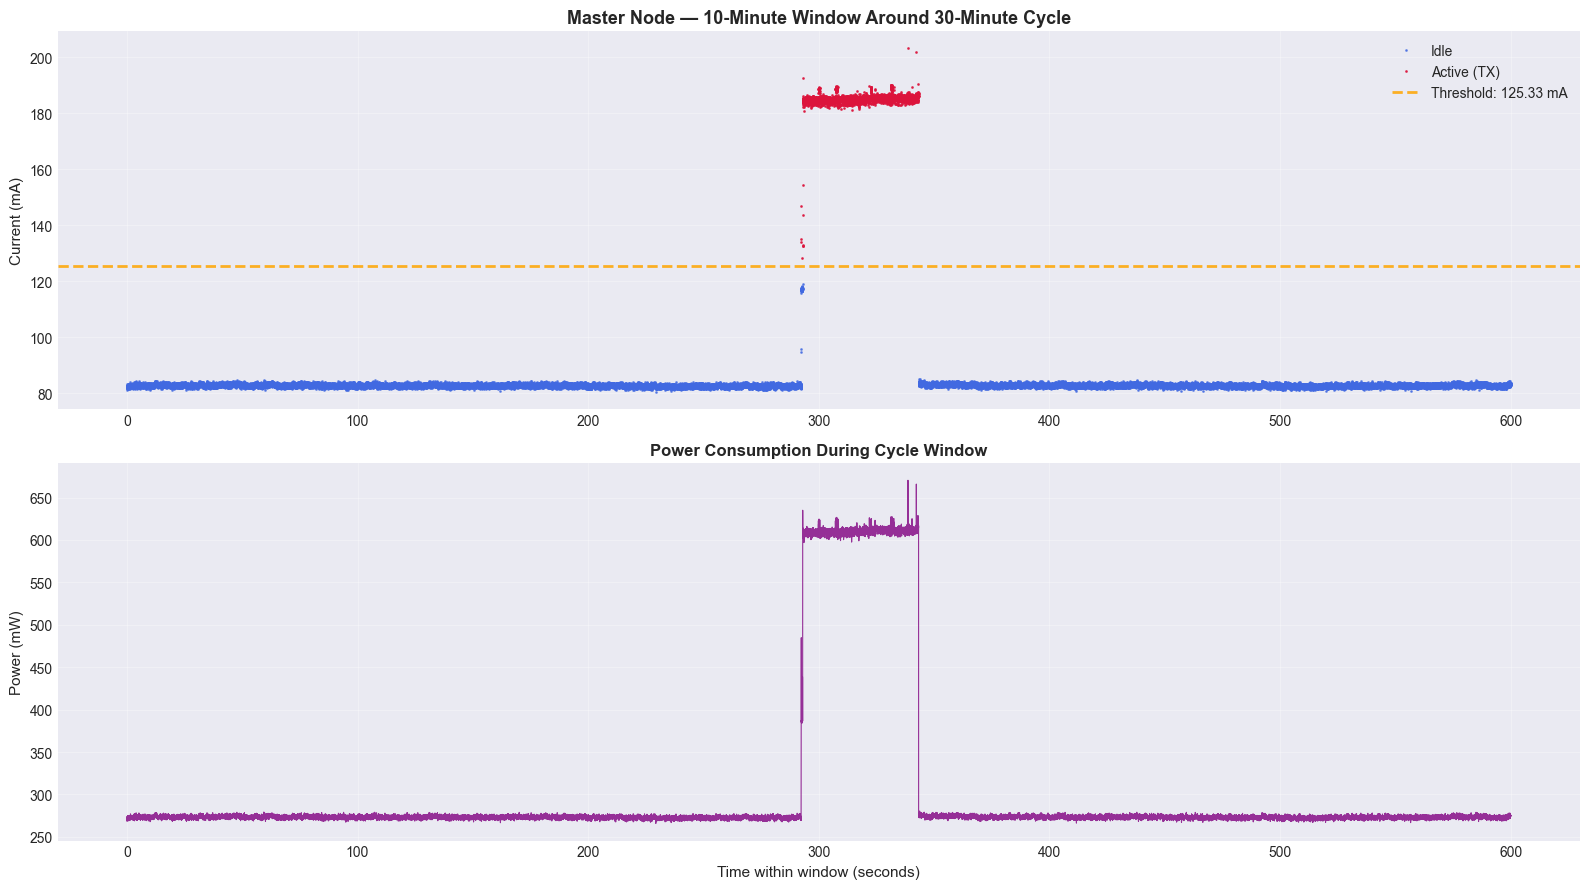

CYCLE ANALYSIS  (25–35 min window, Master Node)
  Threshold : 125.331 mA
  Idle      : 54,968 samples  (91.6%)
  Active    : 5,033 samples  (8.4%)

  Detected 2 activity burst(s):
    Burst 1: 0.02 s  |  avg 138.69 mA  |  peak 146.89 mA
    Burst 2: 50.33 s  |  avg 185.18 mA  |  peak 203.13 mA


In [8]:
if master_df is None:
    print("⚠  Master data not loaded — skipping cycle deep dive.")
else:
    CYCLE_WIN_START = 25 * 60   # 25 min into the hour
    CYCLE_WIN_END   = 35 * 60   # 35 min

    cycle = master_df[
        (master_df['time_sec'] >= CYCLE_WIN_START) &
        (master_df['time_sec'] <= CYCLE_WIN_END)
    ].copy().reset_index(drop=True)
    cycle['rel_sec'] = cycle['time_sec'] - cycle['time_sec'].iloc[0]

    # Classify idle / active
    threshold = master_df['current_ma'].mean() + 1.5 * master_df['current_ma'].std()
    cycle['state'] = np.where(cycle['current_ma'] > threshold, 'active', 'idle')

    idle_mask   = cycle['state'] == 'idle'
    active_mask = cycle['state'] == 'active'

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9))

    # Current with idle/active colouring
    ax1.plot(cycle.loc[idle_mask,   'rel_sec'], cycle.loc[idle_mask,   'current_ma'],
             '.', ms=2, color='royalblue', label='Idle',        alpha=0.7)
    ax1.plot(cycle.loc[active_mask, 'rel_sec'], cycle.loc[active_mask, 'current_ma'],
             '.', ms=2, color='crimson',  label='Active (TX)', alpha=0.8)
    ax1.axhline(threshold, color='orange', linestyle='--', linewidth=2,
                label=f'Threshold: {threshold:.2f} mA', alpha=0.85)
    ax1.set_ylabel('Current (mA)', fontsize=11)
    ax1.set_title('Master Node — 10-Minute Window Around 30-Minute Cycle',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Power consumption
    ax2.plot(cycle['rel_sec'], cycle['power_mw'], linewidth=0.8, color='purple', alpha=0.8)
    ax2.set_xlabel('Time within window (seconds)', fontsize=11)
    ax2.set_ylabel('Power (mW)', fontsize=11)
    ax2.set_title('Power Consumption During Cycle Window', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Burst detection ───────────────────────────────────────────────────────
    print("=" * 65)
    print("CYCLE ANALYSIS  (25–35 min window, Master Node)")
    print("=" * 65)
    print(f"  Threshold : {threshold:.3f} mA")
    print(f"  Idle      : {idle_mask.sum():,} samples  ({idle_mask.mean()*100:.1f}%)")
    print(f"  Active    : {active_mask.sum():,} samples  ({active_mask.mean()*100:.1f}%)")

    if active_mask.sum() > 0:
        act_idx = cycle[active_mask].index.tolist()
        bursts, grp = [], [act_idx[0]]
        for i in range(1, len(act_idx)):
            if act_idx[i] - act_idx[i-1] <= 15:
                grp.append(act_idx[i])
            else:
                bursts.append(grp)
                grp = [act_idx[i]]
        bursts.append(grp)

        print(f"\n  Detected {len(bursts)} activity burst(s):")
        for j, b in enumerate(bursts, 1):
            dur  = (b[-1] - b[0]) / 100        # 100 Hz
            avg  = cycle.loc[b, 'current_ma'].mean()
            peak = cycle.loc[b, 'current_ma'].max()
            print(f"    Burst {j}: {dur:.2f} s  |  avg {avg:.2f} mA  |  peak {peak:.2f} mA")
    print("=" * 65)

## 9. System Energy Statistics and Battery Life Estimates

Full system summary across all available nodes, projected energy consumption, and battery life table.  
A placeholder section for the **MQ3 node** is included — set `PPK2_MQ3_PATH` in cell 1 when ready.

**Expected consumption hierarchy:**  
`Master  >>  Node 1  ≈  Node 2  ≈  MQ3`  
The Master runs the same sensors as the other nodes (DHT22, SGP40, MQ3) but also acts as the UART hub — it receives data from Node 1, Node 2, and the MQ3 node and forwards everything to the Raspberry Pi 5. That extra communication overhead is why it consumes more. The camera is handled entirely by the Pi 5 and is **not** included in these figures.

In [9]:
available = [(name, df, c, lc) for name, (df, c, lc) in NODE_STYLES.items() if df is not None]

# ─────────────────────────────────────────────────────────────────────────────
# ⚠  MQ3 PLACEHOLDER
# When the MQ3 energy file is ready:
#   1. Set PPK2_MQ3_PATH in cell 1
#   2. Re-run cells 1–3 to load the data (mq3_df will be populated automatically)
#   3. Re-run this cell — MQ3 will be included in all totals
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 75)
print("COMPLETE SYSTEM ENERGY SUMMARY")
print("Expected: Master >> Node 1 ≈ Node 2 ≈ MQ3")
print("=" * 75)

total_power_mw = 0
node_power_map = {}
for name, df, color, lc in available:
    duration_h = df['time_sec'].max() / 3600
    energy_mwh = df['power_mw'].mean() * duration_h
    thr         = df['current_ma'].mean() + 1.5 * df['current_ma'].std()
    idle_pct    = (df['current_ma'] <= thr).mean() * 100
    avg_mw      = df['power_mw'].mean()
    total_power_mw += avg_mw
    node_power_map[name] = avg_mw

    print(f"\n{'─'*35}  {name}")
    print(f"  Avg current      : {df['current_ma'].mean():.3f} mA")
    print(f"  Peak current     : {df['current_ma'].max():.3f} mA")
    print(f"  Avg power        : {avg_mw:.3f} mW  ({avg_mw/1000:.5f} W)")
    print(f"  Idle / Active    : {idle_pct:.1f}% idle  /  {100-idle_pct:.1f}% active")
    print(f"  Energy (1 h)     : {energy_mwh:.3f} mWh  ({energy_mwh/1000:.5f} Wh)")
    print(f"  Energy / day     : {energy_mwh*24/1000:.4f} Wh")

if mq3_df is None:
    print(f"\n{'─'*35}  MQ3  (⚠ PENDING — set PPK2_MQ3_PATH in cell 1)")
    print("  Data not yet available.")

# ── Hierarchy validation ──────────────────────────────────────────────────────
print(f"\n{'─'*75}")
print("CONSUMPTION HIERARCHY CHECK")
print(f"{'─'*75}")
m_pw  = node_power_map.get("Master")
n1_pw = node_power_map.get("Node 1")
n2_pw = node_power_map.get("Node 2")
mq_pw = node_power_map.get("MQ3")

if m_pw and n1_pw:
    ok = "✅" if m_pw > n1_pw * 1.2 else "⚠ "
    print(f"  {ok} Master ({m_pw:.2f} mW) >> Node 1 ({n1_pw:.2f} mW)  ×{m_pw/n1_pw:.1f}")
if m_pw and n2_pw:
    ok = "✅" if m_pw > n2_pw * 1.2 else "⚠ "
    print(f"  {ok} Master ({m_pw:.2f} mW) >> Node 2 ({n2_pw:.2f} mW)  ×{m_pw/n2_pw:.1f}")
if n1_pw and n2_pw:
    diff = abs(n1_pw - n2_pw) / max(n1_pw, n2_pw) * 100
    ok   = "✅" if diff < 15 else ("⚠ " if diff < 30 else "❌")
    print(f"  {ok} Node 1 ({n1_pw:.2f} mW) ≈ Node 2 ({n2_pw:.2f} mW)  diff={diff:.1f}%")
if mq_pw is None:
    print(f"  ℹ  MQ3 not yet loaded — cannot validate Node ≈ MQ3")

print(f"\n{'─'*35}  TOTAL SYSTEM  ({len(available)} of 4 nodes loaded)")
total_power_w   = total_power_mw / 1000
total_daily_wh  = total_power_w * 24
total_weekly_wh = total_daily_wh * 7

print(f"  Combined avg power : {total_power_mw:.3f} mW  ({total_power_w:.5f} W)")
print(f"  Daily energy       : {total_daily_wh:.4f} Wh")
print(f"  Weekly energy      : {total_weekly_wh:.3f} Wh")

# ── Battery life table ────────────────────────────────────────────────────────
BATTERIES = [
    ("CR2032 coin cell",     0.225, 3.0, False),
    ("AAA alkaline × 3",    1.2,   1.5, True ),
    ("18650 Li-ion 3000mAh", 3.0,  3.7, False),
    ("LiPo 2000 mAh",        2.0,  3.7, False),
    ("LiPo 5000 mAh",        5.0,  3.7, False),
]

print(f"\n{'─'*75}")
print(f"  BATTERY LIFE ESTIMATES  (total system, {len(available)} nodes loaded)")
print(f"{'─'*75}")
print(f"  {'Battery':<28} {'Capacity (Wh)':>14} {'Hours':>8} {'Days':>7}")
print(f"  {'─'*28} {'─'*14} {'─'*8} {'─'*7}")

for name_b, cap_ah, v, triple in BATTERIES:
    cap_wh = cap_ah * v * (3 if triple else 1)
    hours  = cap_wh / total_power_w
    days   = hours / 24
    print(f"  {name_b:<28} {cap_wh:>14.2f} {hours:>8.1f} {days:>7.1f}")

print("=" * 75)
print("\nNote: estimates assume constant average power (no sleep modes).")
if mq3_df is None:
    print("      MQ3 node is still pending — re-run after adding PPK2_MQ3_PATH.")

COMPLETE SYSTEM ENERGY SUMMARY
Expected: Master >> Node 1 ≈ Node 2 ≈ MQ3

───────────────────────────────────  Master
  Avg current      : 88.789 mA
  Peak current     : 208.440 mA
  Avg power        : 293.003 mW  (0.29300 W)
  Idle / Active    : 94.0% idle  /  6.0% active
  Energy (1 h)     : 293.003 mWh  (0.29300 Wh)
  Energy / day     : 7.0321 Wh

───────────────────────────────────  Node 1
  Avg current      : 64.751 mA
  Peak current     : 232.132 mA
  Avg power        : 213.677 mW  (0.21368 W)
  Idle / Active    : 94.6% idle  /  5.4% active
  Energy (1 h)     : 213.677 mWh  (0.21368 Wh)
  Energy / day     : 5.1283 Wh

───────────────────────────────────  Node 2
  Avg current      : 66.127 mA
  Peak current     : 183.348 mA
  Avg power        : 218.220 mW  (0.21822 W)
  Idle / Active    : 94.6% idle  /  5.4% active
  Energy (1 h)     : 218.220 mWh  (0.21822 Wh)
  Energy / day     : 5.2373 Wh

───────────────────────────────────  MQ3
  Avg current      : 312.865 mA
  Peak current  